<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/13_lstm_final_noleak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB13 — LSTM complementar sem vazamento de informação

## 1. Papel do notebook

Este notebook implementa o **NB13 — LSTM complementar** do pipeline PPCOMP/DM, com foco em avaliar se uma arquitetura sequencial recorrente acrescenta evidência preditiva em relação aos modelos tabulares consolidados no NB11.

A LSTM não substitui automaticamente o modelo tabular principal. Seu papel é **complementar e condicional**: os escores da LSTM só devem ser considerados candidatos ao NB14 se superarem o melhor resultado tabular do NB11 por um ganho mínimo previamente definido em F1 médio no TimeSeriesSplit.

## 2. Motivação

Os notebooks anteriores representaram a dinâmica temporal por meio de atributos causais tabulares, tais como taxa de falha, contagens agregadas e variáveis temporais derivadas. A LSTM é avaliada neste notebook porque sua arquitetura permite tratar explicitamente sequências de observações, usando entradas no formato:

\[
X_t \in \mathbb{R}^{L \times k}
\]

em que:

- \(L\) é o comprimento da sequência histórica;
- \(k\) é o número de atributos causais disponíveis;
- o alvo \(y_t\) permanece sendo a antecipação da entrada em estado crítico dentro do horizonte definido nos notebooks anteriores.

## 3. Princípio metodológico central: evitar leakage

Este notebook foi refeito a partir do zero para corrigir e prevenir vazamento de informação.

A seleção de features é explicitamente controlada. A LSTM **não pode usar**:

- variável-alvo (`y`, `y_nb13` ou equivalentes);
- estados operacionais (`state`, `is_during`, `is_before`, `is_after`, `is_normal`);
- campos de criticidade (`is_critical`, `is_critical_raw`);
- campos de elegibilidade ou horizonte (`eligible_supervised`, `horizon_complete`, `horizon_h`, `h_minutes`);
- parâmetros de cenário ou rotulagem (`k_minutes`, `persistence_minutes`, `threshold_value`);
- identificadores, posição temporal ou tempo absoluto (`bucket_id`, `bucket_start_us`, `row_position`, `timestamp`);
- qualquer campo derivado diretamente do processo de rotulagem.

A coluna `eligible_supervised`, quando existir, pode ser usada apenas para **selecionar os pontos finais elegíveis da tarefa supervisionada**, mas nunca como entrada do modelo.

## 4. Estratégia de construção das sequências

Diferentemente de uma simples filtragem prévia das linhas elegíveis, este notebook constrói sequências sobre a série temporal ordenada, preservando a continuidade temporal. A elegibilidade é aplicada ao **ponto final da sequência**.

Assim, uma sequência que termina no instante \(t\) usa as observações disponíveis em:

\[
[t-L+1, \ldots, t]
\]

e é considerada no treinamento ou teste apenas se o instante final \(t\) for elegível para a tarefa supervisionada.

Essa escolha evita saltos artificiais que poderiam ocorrer se as linhas não elegíveis fossem removidas antes da formação das sequências.

## 5. Protocolo experimental

O notebook executa:

1. corte temporal fixo 80/20, usado como análise complementar;
2. validação temporal por `TimeSeriesSplit`, usada como evidência principal;
3. múltiplas sementes, para avaliar sensibilidade a inicialização;
4. uma pequena varredura controlada de unidades LSTM;
5. avaliação do cenário principal e, se disponível, de um cenário alternativo de 10 minutos.

A varredura de hiperparâmetros é deliberadamente restrita. Ela não constitui uma busca exaustiva, mas uma comparação controlada de configurações pequenas e defensáveis, compatível com o caráter complementar do NB13.

## 6. Critério de decisão

A LSTM será considerada candidata a alimentar o NB14 somente se:

\[
F1_{LSTM,TSCV} \geq F1_{NB11,TSCV} + 0{,}03
\]

Mesmo quando esse critério for satisfeito, a decisão final deve considerar:

- estabilidade entre folds;
- estabilidade entre sementes;
- custo operacional dos erros;
- antecipabilidade dos alertas;
- comparação com os modelos tabulares interpretáveis;
- ausência comprovada de leakage.

## 7. Entregáveis

Este notebook gera artefatos com prefixo `13_lstm_final_noleak_*`, incluindo:

- resultados detalhados do corte fixo;
- resultados detalhados do TimeSeriesSplit;
- resultados agregados;
- escores temporais;
- lista final de features usadas;
- sumário JSON;
- conclusão textual;
- figuras simples de diagnóstico.

Apenas os artefatos com prefixo `13_lstm_final_noleak_*` devem ser considerados válidos para esta versão final do NB13.


Mounted at /content/drive
[2026-05-24 01:15:15] ====================================================================================================
[2026-05-24 01:15:15] NB13 — LSTM complementar sem leakage
[2026-05-24 01:15:15] RUN_TIMESTAMP = 2026-05-24 01:14:54
[2026-05-24 01:15:15] BASE_DIR = /content/drive/MyDrive/Mestrado
[2026-05-24 01:15:15] REPORTS_PATH = /content/drive/MyDrive/Mestrado/04-reports
[2026-05-24 01:15:15] FIGURES_PATH = /content/drive/MyDrive/Mestrado/04-reports/figures_nb13_lstm_final_noleak
[2026-05-24 01:15:15] ====================================================================================================
[2026-05-24 01:15:15] CONFIG:
{
  "main_scenario_id": "W5_K24_H12_P1_TRAIN_M2S",
  "include_main_scenario": true,
  "include_best_10min_if_available": true,
  "include_p2_sensitivity": false,
  "sequence_length": 24,
  "dropout": 0.2,
  "learning_rate": 0.001,
  "validation_fraction_from_train": 0.2,
  "fixed_train_fraction": 0.8,
  "classification_thre

,column,reason
0,bucket_id,forbidden_name_or_pattern
1,bucket_start_us,forbidden_name_or_pattern
2,row_position,forbidden_name_or_pattern
3,window_minutes,forbidden_name_or_pattern
4,k_before_after,forbidden_name_or_pattern
5,horizon_h,forbidden_name_or_pattern
6,k_minutes,forbidden_name_or_pattern
7,h_minutes,forbidden_name_or_pattern
8,threshold_value,forbidden_name_or_pattern
9,persistence_min_windows,forbidden_name_or_pattern


[2026-05-24 01:15:38] [FIXED] Iniciando avaliação 80/20
[2026-05-24 01:15:38] [FIXED SETUP] cenário=W5_K24_H12_P1_TRAIN_M2S | n_seq=6954 | treino_seq=5563 | teste_seq=1391
[2026-05-24 01:15:38] [TREINO] FIXED | scenario=W5_K24_H12_P1_TRAIN_M2S | units=8 | seed=42 | X_train=(5563, 24, 7) | X_val=(1113, 24, 7) | X_test=(1391, 24, 7) | pos_train=1602/5563
[2026-05-24 01:15:49] [FIM] FIXED | scenario=W5_K24_H12_P1_TRAIN_M2S | units=8 | seed=42 | total=0.19 min | epochs=14 | best_val_loss=0.599667
[2026-05-24 01:15:50] [TREINO] FIXED | scenario=W5_K24_H12_P1_TRAIN_M2S | units=8 | seed=123 | X_train=(5563, 24, 7) | X_val=(1113, 24, 7) | X_test=(1391, 24, 7) | pos_train=1602/5563
[2026-05-24 01:16:02] [FIM] FIXED | scenario=W5_K24_H12_P1_TRAIN_M2S | units=8 | seed=123 | total=0.21 min | epochs=15 | best_val_loss=0.593601
[2026-05-24 01:16:03] [TREINO] FIXED | scenario=W5_K24_H12_P1_TRAIN_M2S | units=8 | seed=2026 | X_train=(5563, 24, 7) | X_val=(1113, 24, 7) | X_test=(1391, 24, 7) | pos_train

,column,reason
0,bucket_id,forbidden_name_or_pattern
1,bucket_start_us,forbidden_name_or_pattern
2,row_position,forbidden_name_or_pattern
3,window_minutes,forbidden_name_or_pattern
4,k_before_after,forbidden_name_or_pattern
5,horizon_h,forbidden_name_or_pattern
6,k_minutes,forbidden_name_or_pattern
7,h_minutes,forbidden_name_or_pattern
8,threshold_value,forbidden_name_or_pattern
9,persistence_min_windows,forbidden_name_or_pattern


[2026-05-24 01:24:26] [FIXED] Iniciando avaliação 80/20
[2026-05-24 01:24:26] [FIXED SETUP] cenário=W10_K12_H6_P1_TRAIN_M2S | n_seq=3651 | treino_seq=2920 | teste_seq=731
[2026-05-24 01:24:26] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=8 | seed=42 | X_train=(2920, 24, 7) | X_val=(584, 24, 7) | X_test=(731, 24, 7) | pos_train=421/2920
[2026-05-24 01:24:36] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=8 | seed=42 | total=0.16 min | epochs=14 | best_val_loss=0.690991
[2026-05-24 01:24:37] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=8 | seed=123 | X_train=(2920, 24, 7) | X_val=(584, 24, 7) | X_test=(731, 24, 7) | pos_train=421/2920


[2026-05-24 01:24:45] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=8 | seed=123 | total=0.13 min | epochs=14 | best_val_loss=0.669590
[2026-05-24 01:24:47] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=8 | seed=2026 | X_train=(2920, 24, 7) | X_val=(584, 24, 7) | X_test=(731, 24, 7) | pos_train=421/2920


[2026-05-24 01:24:55] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=8 | seed=2026 | total=0.13 min | epochs=11 | best_val_loss=0.690012
[2026-05-24 01:24:56] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=16 | seed=42 | X_train=(2920, 24, 7) | X_val=(584, 24, 7) | X_test=(731, 24, 7) | pos_train=421/2920
[2026-05-24 01:25:05] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=16 | seed=42 | total=0.15 min | epochs=12 | best_val_loss=0.651534
[2026-05-24 01:25:07] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=16 | seed=123 | X_train=(2920, 24, 7) | X_val=(584, 24, 7) | X_test=(731, 24, 7) | pos_train=421/2920
[2026-05-24 01:25:13] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=16 | seed=123 | total=0.11 min | epochs=10 | best_val_loss=0.654577
[2026-05-24 01:25:15] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | units=16 | seed=2026 | X_train=(2920, 24, 7) | X_val=(584, 24, 7) | X_test=(731, 24, 7) | pos_train=421/2920
[2026-05-24 01:25:24

,scenario_id,protocol,feature_mode,units,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,...,positive_rate_mean,positive_rate_std,epochs_ran_mean,epochs_ran_std,best_val_loss_mean,best_val_loss_std,fit_elapsed_seconds_mean,fit_elapsed_seconds_std,total_elapsed_seconds_mean,total_elapsed_seconds_std
2,W5_K24_H12_P1_TRAIN_M2S,fixed_80_20,multivariate_final_noleak,8,0.765876,0.005766,0.782354,0.006538,0.935859,0.022212,...,0.721064,0.0,14.666667,0.577350,0.600367,0.007143,11.642104,0.731585,12.040126,0.741362
3,W5_K24_H12_P1_TRAIN_M2S,fixed_80_20,multivariate_final_noleak,16,0.753654,0.006833,0.793490,0.010640,0.890329,0.013413,...,0.721064,0.0,12.000000,1.000000,0.588273,0.002893,11.842077,0.506881,12.242536,0.501903
1,W10_K12_H6_P1_TRAIN_M2S,fixed_80_20,multivariate_final_noleak,16,0.697674,0.021369,0.659036,0.021830,0.927318,0.013023,...,0.545828,0.0,11.666667,1.527525,0.648593,0.007878,7.883423,1.479783,8.258920,1.472262
0,W10_K12_H6_P1_TRAIN_M2S,fixed_80_20,multivariate_final_noleak,8,0.670315,0.038377,0.631162,0.035511,0.965748,0.038366,...,0.545828,0.0,13.000000,1.732051,0.683531,0.012083,7.822228,0.730442,8.310220,0.921289


[2026-05-24 01:31:53] Resultados agregados TSCV:


,scenario_id,protocol,feature_mode,units,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,...,positive_rate_mean,positive_rate_std,epochs_ran_mean,epochs_ran_std,best_val_loss_mean,best_val_loss_std,fit_elapsed_seconds_mean,fit_elapsed_seconds_std,total_elapsed_seconds_mean,total_elapsed_seconds_std
2,W5_K24_H12_P1_TRAIN_M2S,tscv,multivariate_final_noleak,8,0.631176,0.121241,0.473258,0.271043,0.700633,0.275418,...,0.433477,0.237262,28.200000,15.776112,0.585250,0.061564,14.352919,5.919403,14.838952,5.896243
3,W5_K24_H12_P1_TRAIN_M2S,tscv,multivariate_final_noleak,16,0.623066,0.120178,0.469185,0.279471,0.675658,0.272841,...,0.433477,0.237262,22.733333,14.355022,0.578952,0.062239,12.555356,5.794800,12.975610,5.776850
1,W10_K12_H6_P1_TRAIN_M2S,tscv,multivariate_final_noleak,16,0.595175,0.114336,0.337817,0.232655,0.695279,0.247884,...,0.265789,0.181408,22.200000,17.259366,0.591704,0.151362,10.256924,5.310785,10.723399,5.300702
0,W10_K12_H6_P1_TRAIN_M2S,tscv,multivariate_final_noleak,8,0.607456,0.110844,0.329762,0.219118,0.701766,0.277730,...,0.265789,0.181408,25.266667,17.798341,0.603694,0.140247,10.561029,5.025294,10.944536,5.022473


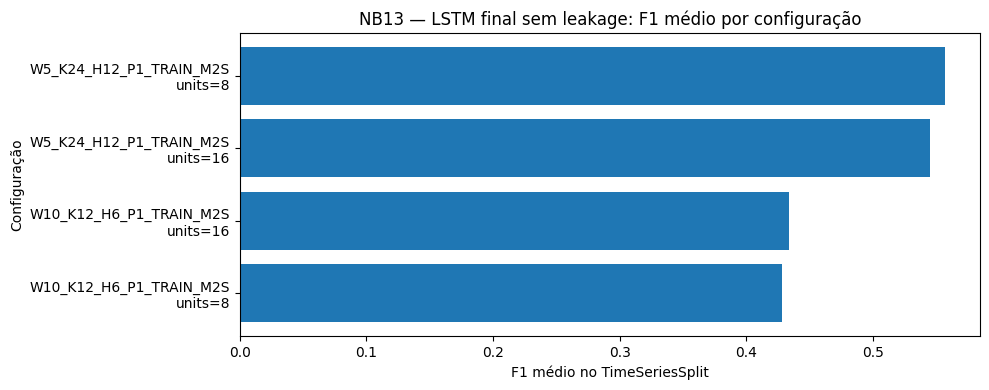

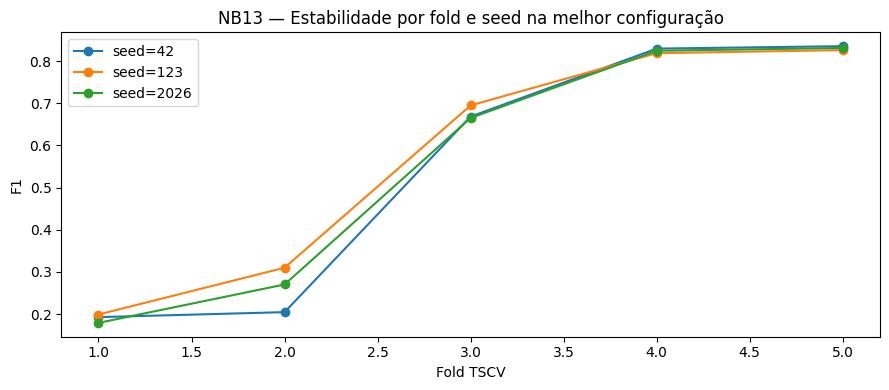

[2026-05-24 01:31:54] ====================================================================================================
[2026-05-24 01:31:54] FIM DO NB13 — LSTM FINAL SEM LEAKAGE
[2026-05-24 01:31:54] Tempo total: 16.28 min
[2026-05-24 01:31:54] fixed_results: (12, 29)
[2026-05-24 01:31:54] tscv_results: (60, 29)
[2026-05-24 01:31:54] scores_df: (65742, 12)
[2026-05-24 01:31:54] Melhor F1 TSCV LSTM: 0.5565522405725165
[2026-05-24 01:31:54] Melhor F1 TSCV NB11: 0.5773731424098736
[2026-05-24 01:31:54] Delta LSTM - NB11: -0.020820901837357075
[2026-05-24 01:31:54] Decisão NB14: keep_nb11_scores_for_nb14

Artefatos salvos:
- /content/drive/MyDrive/Mestrado/04-reports/13_lstm_final_noleak_fixed_results.csv
- /content/drive/MyDrive/Mestrado/04-reports/13_lstm_final_noleak_tscv_results.csv
- /content/drive/MyDrive/Mestrado/04-reports/13_lstm_final_noleak_fixed_results_agg.csv
- /content/drive/MyDrive/Mestrado/04-reports/13_lstm_final_noleak_tscv_results_agg.csv
- /content/drive/MyDrive/Me

,n,n_positive,positive_rate,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,...,units,feature_mode,n_features,sequence_length,epochs_ran,best_val_loss,last_val_loss,fit_elapsed_seconds,total_elapsed_seconds,class_weight
0,1391,1003,0.721064,0.5,0.771387,0.781893,0.947159,0.856628,0.743491,0.845524,...,8,multivariate_final_noleak,7,24,14,0.599667,0.622862,10.798570,11.185269,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
1,1391,1003,0.721064,0.5,0.759885,0.789110,0.910269,0.845370,0.744532,0.857960,...,8,multivariate_final_noleak,7,24,15,0.593601,0.609655,12.103298,12.506693,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
2,1391,1003,0.721064,0.5,0.766355,0.776059,0.950150,0.854325,0.756866,0.865108,...,8,multivariate_final_noleak,7,24,15,0.607835,0.621114,12.024443,12.428416,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
3,1391,1003,0.721064,0.5,0.760604,0.798043,0.894317,0.843441,0.737167,0.854480,...,16,multivariate_final_noleak,7,24,12,0.589275,0.646915,12.099249,12.497881,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
4,1391,1003,0.721064,0.5,0.753415,0.801095,0.875374,0.836589,0.752076,0.870182,...,16,multivariate_final_noleak,7,24,11,0.585012,0.642502,11.258161,11.664302,"{0: 0.6399194708081679, 1: 2.2867420349434737}"



Amostra tscv_results:


,n,n_positive,positive_rate,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,...,units,feature_mode,n_features,sequence_length,epochs_ran,best_val_loss,last_val_loss,fit_elapsed_seconds,total_elapsed_seconds,class_weight
0,1159,240,0.207075,0.5,0.400345,0.133655,0.345833,0.192799,0.336820,0.152310,...,8,multivariate_final_noleak,7,24,29,0.557514,0.570358,10.272840,10.864044,"{0: 0.5346020761245674, 1: 7.725}"
1,1159,240,0.207075,0.5,0.437446,0.141115,0.337500,0.199017,0.368902,0.165667,...,8,multivariate_final_noleak,7,24,37,0.526050,0.555758,11.749330,12.309725,"{0: 0.5346020761245674, 1: 7.725}"
2,1159,240,0.207075,0.5,0.470233,0.131890,0.279167,0.179144,0.372148,0.155522,...,8,multivariate_final_noleak,7,24,47,0.564168,0.570200,14.766412,15.171009,"{0: 0.5346020761245674, 1: 7.725}"
3,1159,240,0.207075,0.5,0.415013,0.126280,0.308333,0.179177,0.331198,0.146967,...,16,multivariate_final_noleak,7,24,26,0.552727,0.593995,8.391448,9.053772,"{0: 0.5346020761245674, 1: 7.725}"
4,1159,240,0.207075,0.5,0.411562,0.136513,0.345833,0.195755,0.352757,0.157017,...,16,multivariate_final_noleak,7,24,27,0.529923,0.568004,9.751035,10.154921,"{0: 0.5346020761245674, 1: 7.725}"


In [1]:

# ============================================================
# NB13 — LSTM complementar sem leakage
# Código completo em célula única
# Pipeline PPCOMP/DM
# ============================================================

# Observação:
# Este notebook foi desenhado para ser executado após os artefatos do NB10/NB11
# já existirem no Google Drive. Ele carrega diretamente os artefatos consolidados,
# monta sequências temporais sem vazamento de informação e gera novos artefatos
# com prefixo 13_lstm_final_noleak_*.

import os
import re
import gc
import json
import time
import math
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 0. TensorFlow / Keras
# ------------------------------------------------------------

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
except Exception as exc:
    TENSORFLOW_AVAILABLE = False
    TF_IMPORT_ERROR = repr(exc)

if not TENSORFLOW_AVAILABLE:
    raise ImportError(
        "TensorFlow/Keras não está disponível neste ambiente. "
        f"Erro original: {TF_IMPORT_ERROR}"
    )

# ------------------------------------------------------------
# 1. Utilidades de log
# ------------------------------------------------------------

RUN_TAG = "final_noleak"
RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def log(msg):
    print(f"[{now_str()}] {msg}", flush=True)

def safe_json_dump(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

# ------------------------------------------------------------
# 2. Montagem opcional do Google Drive
# ------------------------------------------------------------

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        log(f"[AVISO] Não foi possível montar o Google Drive automaticamente: {exc}")

# ------------------------------------------------------------
# 3. Diretórios
# ------------------------------------------------------------

BASE_DIR = (
    Path("/content/drive/MyDrive/Mestrado")
    if Path("/content/drive/MyDrive/Mestrado").exists()
    else Path.cwd()
)

FEATURES_PATH = ensure_dir(BASE_DIR / "02-datasets" / "03-features")
MODELS_PATH = ensure_dir(BASE_DIR / "03-models")
REPORTS_PATH = ensure_dir(BASE_DIR / "04-reports")
FIGURES_PATH = ensure_dir(REPORTS_PATH / "figures_nb13_lstm_final_noleak")

log("=" * 100)
log("NB13 — LSTM complementar sem leakage")
log(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")
log(f"BASE_DIR = {BASE_DIR}")
log(f"REPORTS_PATH = {REPORTS_PATH}")
log(f"FIGURES_PATH = {FIGURES_PATH}")
log("=" * 100)

# ------------------------------------------------------------
# 4. Configuração experimental
# ------------------------------------------------------------

# RUN_MODE controla o esforço computacional.
# - "SMOKE": teste mínimo de funcionamento.
# - "FINAL_LIGHT": execução recomendada para fechar o NB13 com custo moderado.
# - "FULL": execução mais ampla, ainda sem busca exaustiva.
RUN_MODE = "FINAL_LIGHT"

CONFIG = {
    "main_scenario_id": "W5_K24_H12_P1_TRAIN_M2S",

    # Cenários
    "include_main_scenario": True,
    "include_best_10min_if_available": True,
    "include_p2_sensitivity": False,

    # Sequência
    "sequence_length": 24,

    # Treinamento e arquitetura
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "validation_fraction_from_train": 0.20,
    "fixed_train_fraction": 0.80,
    "classification_threshold": 0.50,

    # Critério metodológico para NB14
    "min_delta_f1_to_feed_nb14": 0.03,

    # Controle
    "filter_to_eligible_supervised_endpoints": True,
    "save_keras_models": False,
    "keras_verbose": 0,

    # Rótulo do experimento
    "run_mode": RUN_MODE,
}

if RUN_MODE == "SMOKE":
    CONFIG.update({
        "lstm_units_grid": [8],
        "seeds": [42],
        "tscv_splits": 2,
        "max_epochs": 10,
        "batch_size": 128,
        "early_stopping_patience": 3,
        "reduce_lr_patience": 2,
        "include_best_10min_if_available": False,
        "keras_verbose": 1,
    })
elif RUN_MODE == "FINAL_LIGHT":
    CONFIG.update({
        "lstm_units_grid": [8, 16],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 50,
        "batch_size": 128,
        "early_stopping_patience": 8,
        "reduce_lr_patience": 4,
        "keras_verbose": 0,
    })
elif RUN_MODE == "FULL":
    CONFIG.update({
        "lstm_units_grid": [8, 16, 32],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 100,
        "batch_size": 128,
        "early_stopping_patience": 12,
        "reduce_lr_patience": 5,
        "keras_verbose": 0,
    })
else:
    raise ValueError(f"RUN_MODE inválido: {RUN_MODE}")

log("CONFIG:")
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

# ------------------------------------------------------------
# 5. Localização e carregamento dos artefatos
# ------------------------------------------------------------

def find_first_existing(candidates):
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    return None

NB10_STATES_PATH = find_first_existing([
    REPORTS_PATH / "10_scenario_series_states.parquet",
    FEATURES_PATH / "10_scenario_series_states.parquet",
    BASE_DIR / "10_scenario_series_states.parquet",
])

NB10_EPISODES_PATH = find_first_existing([
    REPORTS_PATH / "10_scenario_episodes.parquet",
    FEATURES_PATH / "10_scenario_episodes.parquet",
    BASE_DIR / "10_scenario_episodes.parquet",
])

NB10_ADVANCED_PATH = find_first_existing([
    REPORTS_PATH / "10_scenario_advanced_to_nb11.json",
    FEATURES_PATH / "10_scenario_advanced_to_nb11.json",
    BASE_DIR / "10_scenario_advanced_to_nb11.json",
])

if NB10_STATES_PATH is None:
    raise FileNotFoundError(
        "Não encontrei 10_scenario_series_states.parquet. "
        "Verifique se o NB10 foi executado e se os artefatos estão em 04-reports."
    )

states_all = pd.read_parquet(NB10_STATES_PATH)
states_all = states_all.loc[:, ~states_all.columns.duplicated()].copy()

episodes_all = pd.read_parquet(NB10_EPISODES_PATH) if NB10_EPISODES_PATH else pd.DataFrame()

if NB10_ADVANCED_PATH and NB10_ADVANCED_PATH.exists():
    with open(NB10_ADVANCED_PATH, "r", encoding="utf-8") as f:
        advanced_json = json.load(f)
else:
    advanced_json = {}

log(f"NB10_STATES_PATH = {NB10_STATES_PATH}")
log(f"states_all.shape = {states_all.shape}")
log(f"episodes_all.shape = {episodes_all.shape}")
log(f"NB10_ADVANCED_PATH = {NB10_ADVANCED_PATH}")

# ------------------------------------------------------------
# 6. Inferência de colunas estruturais
# ------------------------------------------------------------

def infer_scenario_col(df):
    for c in ["scenario_id", "scenario", "cenario", "scenario_name", "scenario_key"]:
        if c in df.columns:
            return c
    raise ValueError("Não foi possível identificar coluna de cenário.")

def infer_time_col(df):
    for c in [
        "bucket_start",
        "bucket_start_dt",
        "bucket_start_datetime",
        "timestamp",
        "datetime",
        "time",
        "window_start",
        "dt",
    ]:
        if c in df.columns:
            return c
    if "bucket_start_us" in df.columns:
        return "bucket_start_us"
    if "bucket_id" in df.columns:
        return "bucket_id"
    raise ValueError("Não foi possível identificar coluna temporal para ordenação.")

SCENARIO_COL = infer_scenario_col(states_all)
TIME_COL = infer_time_col(states_all)

available_scenarios = sorted(states_all[SCENARIO_COL].dropna().astype(str).unique())

log(f"SCENARIO_COL = {SCENARIO_COL}")
log(f"TIME_COL = {TIME_COL}")
log(f"Quantidade de cenários disponíveis = {len(available_scenarios)}")
print("Cenários disponíveis:")
print(available_scenarios)

# ------------------------------------------------------------
# 7. Seleção de cenários
# ------------------------------------------------------------

def extract_advanced_scenarios(advanced_json, fallback_scenarios):
    found = []

    def walk(obj):
        if isinstance(obj, dict):
            for k, v in obj.items():
                if isinstance(v, (dict, list)):
                    walk(v)
                elif isinstance(v, str):
                    if re.match(r"^W\d+_K\d+_H\d+_P\d+_", v):
                        found.append(v)
                    elif k.lower() in {"scenario", "scenario_id", "cenario", "scenario_key"}:
                        found.append(v)
        elif isinstance(obj, list):
            for item in obj:
                walk(item)
        elif isinstance(obj, str):
            if re.match(r"^W\d+_K\d+_H\d+_P\d+_", obj):
                found.append(obj)

    walk(advanced_json)
    found = sorted(set([x for x in found if isinstance(x, str)]))

    if found:
        return found

    return [s for s in fallback_scenarios if "TRAIN_M2S" in s or "TRAIN_P95" in s]

advanced_scenarios = extract_advanced_scenarios(advanced_json, available_scenarios)

def select_run_scenarios(available_scenarios, advanced_scenarios, config):
    selected = []

    main = config["main_scenario_id"]

    if config.get("include_main_scenario", True) and main in available_scenarios:
        selected.append(main)
    elif config.get("include_main_scenario", True):
        log(f"[AVISO] Cenário principal não encontrado: {main}")

    if config.get("include_p2_sensitivity", False):
        p2 = main.replace("_P1_", "_P2_")
        if p2 in available_scenarios:
            selected.append(p2)

    if config.get("include_best_10min_if_available", True):
        ten_min_candidates = [
            s for s in advanced_scenarios
            if str(s).startswith("W10_") and s in available_scenarios
        ]

        if not ten_min_candidates:
            ten_min_candidates = [
                s for s in available_scenarios
                if str(s).startswith("W10_") and "TRAIN_M2S" in str(s)
            ]

        if ten_min_candidates:
            ten_min_candidates = sorted(
                ten_min_candidates,
                key=lambda s: (
                    0 if "TRAIN_M2S" in s else 1,
                    0 if "_P1_" in s else 1,
                    s
                )
            )
            selected.append(ten_min_candidates[0])

    selected = list(dict.fromkeys(selected))

    if not selected:
        raise ValueError("Nenhum cenário foi selecionado para o NB13.")

    return selected

RUN_SCENARIOS = select_run_scenarios(available_scenarios, advanced_scenarios, CONFIG)

log("Cenários selecionados para o NB13:")
print(RUN_SCENARIOS)

# ------------------------------------------------------------
# 8. Referência do NB11
# ------------------------------------------------------------

def try_load_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

def flatten_json(obj, prefix=""):
    rows = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            key = f"{prefix}.{k}" if prefix else str(k)
            if isinstance(v, dict):
                rows.update(flatten_json(v, key))
            else:
                rows[key] = v
    return rows

def find_nb11_reference(report_paths):
    json_candidates = []
    csv_candidates = []

    for base in report_paths:
        base = Path(base)
        json_candidates += list(base.glob("**/11*summary*.json"))
        json_candidates += list(base.glob("**/*nb11*summary*.json"))
        json_candidates += list(base.glob("**/11*results*.json"))
        csv_candidates += list(base.glob("**/11*results*.csv"))
        csv_candidates += list(base.glob("**/*nb11*results*.csv"))
        csv_candidates += list(base.glob("**/11*model*.csv"))

    for path in sorted(set(json_candidates)):
        data = try_load_json(path)
        if data is None:
            continue

        flat = flatten_json(data)
        candidates = []

        for k, v in flat.items():
            lk = k.lower()
            if "f1" in lk and ("tscv" in lk or "timeseries" in lk) and ("mean" in lk or "media" in lk):
                try:
                    candidates.append((k, float(v)))
                except Exception:
                    pass

        if candidates:
            best_key, best_val = sorted(candidates, key=lambda x: x[1], reverse=True)[0]
            return {
                "source_path": str(path),
                "best_f1_tscv_mean": float(best_val),
                "best_key": best_key,
                "raw_source_type": "json",
            }

    for path in sorted(set(csv_candidates)):
        try:
            df = pd.read_csv(path)
        except Exception:
            continue

        f1_cols = [c for c in df.columns if "f1" in c.lower()]
        protocol_cols = [
            c for c in df.columns
            if any(x in c.lower() for x in ["protocol", "valid", "split", "cv"])
        ]

        if not f1_cols:
            continue

        df2 = df.copy()

        if protocol_cols:
            mask = np.zeros(len(df2), dtype=bool)
            for pc in protocol_cols:
                mask |= df2[pc].astype(str).str.lower().str.contains(
                    "tscv|time|series",
                    regex=True,
                    na=False
                ).values
            if mask.any():
                df2 = df2.loc[mask].copy()

        preferred = [c for c in f1_cols if "mean" in c.lower() or "media" in c.lower()]
        f1_col = preferred[0] if preferred else f1_cols[0]

        vals = pd.to_numeric(df2[f1_col], errors="coerce")

        if vals.notna().any():
            idx = vals.idxmax()
            row = df2.loc[idx].to_dict()
            return {
                "source_path": str(path),
                "best_f1_tscv_mean": float(vals.loc[idx]),
                "best_key": f1_col,
                "best_row": row,
                "raw_source_type": "csv",
            }

    return None

NB11_REFERENCE = find_nb11_reference([REPORTS_PATH, BASE_DIR, FEATURES_PATH])

log("Referência NB11:")
print(json.dumps(NB11_REFERENCE, indent=2, ensure_ascii=False) if NB11_REFERENCE else "Não encontrada automaticamente.")

# ------------------------------------------------------------
# 9. Seleção segura de features
# ------------------------------------------------------------

TARGET_CANDIDATES = [
    "y",
    "target",
    "label",
    "y_binary",
    "y_future",
    "future_during",
    "future_during_within_h",
    "failure_within_h",
    "critical_future",
    "will_fail",
    "will_be_critical",
]

# Lista explícita de features causais aceitas.
# Só serão usadas as colunas existentes no artefato carregado.
PREFERRED_SAFE_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",

    "event_FAIL_count",
    "event_LOST_count",
    "event_SCHEDULE_count",
    "event_FINISH_count",
    "event_ENABLE_count",
    "event_EVICT_count",
    "event_KILL_count",

    "mean_priority",
    "mean_req_cpus",
    "mean_req_mem",
    "req_cpus_presence_rate",
    "req_mem_presence_rate",

    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

FORBIDDEN_EXACT = {
    # Alvos
    "y",
    "y_nb13",
    "target",
    "label",
    "y_binary",
    "y_future",
    "future_during",
    "future_during_within_h",
    "failure_within_h",
    "critical_future",
    "will_fail",
    "will_be_critical",

    # Estados e rótulos auxiliares
    "state",
    "operational_state",
    "estado",
    "phase",
    "episode_state",
    "is_critical",
    "is_critical_raw",
    "is_during",
    "is_before",
    "is_after",
    "is_normal",
    "horizon_complete",
    "eligible_supervised",

    # Parâmetros de cenário/rotulagem
    "window_minutes",
    "k_before_after",
    "horizon_h",
    "k_minutes",
    "h_minutes",
    "threshold_value",
    "persistence_min_windows",
    "persistence_minutes",

    # Identificadores, posição e tempo absoluto
    "row_position",
    "bucket_id",
    "bucket_start_us",
    "bucket_start",
    "bucket_start_dt",
    "bucket_start_datetime",
    "timestamp",
    "datetime",
    "time",
    "window_start",
    "dt",

    # Cenário
    "scenario",
    "scenario_id",
    "scenario_name",
    "scenario_key",
    "cenario",
}

FORBIDDEN_PATTERNS = [
    r"^y$",
    r"^y_",
    r"target",
    r"label",
    r"future",
    r"will_",
    r"ahead",
    r"state",
    r"estado",
    r"phase",
    r"during",
    r"before",
    r"after",
    r"episode",
    r"critical",
    r"normal",
    r"eligible",
    r"horizon",
    r"persistence",
    r"threshold",
    r"limiar",
    r"scenario",
    r"cenario",
    r"bucket",
    r"timestamp",
    r"datetime",
    r"row_position",
    r"score",
    r"prob",
    r"pred",
    r"fold",
    r"split",
]

def is_forbidden_feature(col):
    c = str(col)
    lc = c.lower()

    if c in FORBIDDEN_EXACT or lc in FORBIDDEN_EXACT:
        return True

    for pattern in FORBIDDEN_PATTERNS:
        if re.search(pattern, lc):
            return True

    return False

def infer_target_col(df):
    for c in TARGET_CANDIDATES:
        if c in df.columns:
            vals = set(pd.Series(df[c]).dropna().unique())
            if vals.issubset({0, 1, False, True}) or len(vals) <= 3:
                return c

    raise ValueError(
        "Não encontrei coluna-alvo binária. Esperava encontrar 'y' ou equivalente."
    )

def select_safe_features(df, target_col):
    existing_preferred = [
        c for c in PREFERRED_SAFE_FEATURES
        if c in df.columns and c != target_col and not is_forbidden_feature(c)
    ]

    numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    rejected = []

    for c in numeric_cols:
        if c == target_col:
            rejected.append((c, "target_col"))
        elif is_forbidden_feature(c):
            rejected.append((c, "forbidden_name_or_pattern"))
        elif c not in existing_preferred:
            rejected.append((c, "not_in_preferred_feature_list"))

    if existing_preferred:
        selected = existing_preferred
        source = "preferred_safe_feature_list"
    else:
        selected = [
            c for c in numeric_cols
            if c != target_col and not is_forbidden_feature(c)
        ]
        source = "fallback_numeric_non_forbidden"

    selected = list(dict.fromkeys(selected))

    bad = [c for c in selected if is_forbidden_feature(c)]
    if bad:
        raise AssertionError(f"LEAKAGE DETECTADO: colunas proibidas selecionadas: {bad}")

    if "y" in selected or "y_nb13" in selected or target_col in selected:
        raise AssertionError(
            f"LEAKAGE DETECTADO: alvo entrou nas features. selected={selected}"
        )

    if not selected:
        raise ValueError("Nenhuma feature segura foi selecionada.")

    return selected, rejected, source

# ------------------------------------------------------------
# 10. Preparação do cenário e das sequências
# ------------------------------------------------------------

def prepare_scenario_dataframe(states_all, scenario_id):
    df = states_all.loc[
        states_all[SCENARIO_COL].astype(str) == str(scenario_id)
    ].copy()

    if df.empty:
        raise ValueError(f"Cenário {scenario_id} não encontrado.")

    df = df.loc[:, ~df.columns.duplicated()].copy()

    if "y_nb13" in df.columns:
        df = df.drop(columns=["y_nb13"])

    df = df.sort_values(TIME_COL).reset_index(drop=True)

    target_col = infer_target_col(df)

    df["y_nb13"] = (
        pd.to_numeric(df[target_col], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if CONFIG.get("filter_to_eligible_supervised_endpoints", True) and "eligible_supervised" in df.columns:
        endpoint_eligible = (
            pd.to_numeric(df["eligible_supervised"], errors="coerce")
            .fillna(0)
            .astype(int)
            .to_numpy()
        )
        endpoint_eligibility_source = "eligible_supervised"
    else:
        endpoint_eligible = np.ones(len(df), dtype=int)
        endpoint_eligibility_source = "all_rows"

    feature_columns, rejected_columns, feature_source = select_safe_features(
        df,
        target_col=target_col
    )

    # Mantém a série completa, preservando continuidade temporal.
    keep_cols = [TIME_COL, SCENARIO_COL, "y_nb13"] + feature_columns
    keep_cols = list(dict.fromkeys(keep_cols))

    df_model = df[keep_cols].copy()
    df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()

    # Imputação causal simples:
    # - substitui inf por NaN;
    # - forward-fill preservando ordem temporal;
    # - NaNs iniciais por zero.
    # Isso evita remover linhas e quebrar a continuidade da sequência.
    df_model[feature_columns] = (
        df_model[feature_columns]
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .fillna(0)
    )

    y_arr = df_model["y_nb13"].to_numpy(dtype=int)

    diagnostics = {
        "scenario_id": scenario_id,
        "n_rows_full_series": int(len(df_model)),
        "n_positive_full_series": int(y_arr.sum()),
        "positive_rate_full_series": float(y_arr.mean()) if len(y_arr) else np.nan,
        "target_source": target_col,
        "feature_source": feature_source,
        "endpoint_eligibility_source": endpoint_eligibility_source,
        "n_endpoint_eligible_raw": int(endpoint_eligible.sum()),
        "n_features": int(len(feature_columns)),
        "feature_columns": feature_columns,
        "rejected_columns": rejected_columns,
        "imputation_strategy": "causal_ffill_then_zero",
        "leakage_statement": (
            "A variável-alvo, estados, criticidade, elegibilidade, horizonte, "
            "parâmetros de cenário, posição temporal e tempo absoluto foram excluídos "
            "das features. A elegibilidade é usada apenas para selecionar pontos finais."
        ),
    }

    return df_model, feature_columns, endpoint_eligible, diagnostics

def make_sequence_end_positions(n_rows, sequence_length, endpoint_eligible):
    base = np.arange(sequence_length - 1, n_rows, dtype=int)
    eligible_base = base[endpoint_eligible[base].astype(bool)]
    return eligible_base

def build_X_y_from_scaled_values(values_scaled, y, end_positions, sequence_length):
    X = np.empty(
        (len(end_positions), sequence_length, values_scaled.shape[1]),
        dtype=np.float32
    )
    y_out = np.empty(len(end_positions), dtype=np.int32)

    for j, end in enumerate(end_positions):
        start = end - sequence_length + 1
        X[j] = values_scaled[start:end + 1, :]
        y_out[j] = y[end]

    return X, y_out

def scale_and_build_sequences_for_split(
    df,
    feature_columns,
    end_positions,
    train_seq_idx,
    test_seq_idx,
    sequence_length
):
    raw_values = df[feature_columns].to_numpy(dtype=np.float32)
    y_raw = df["y_nb13"].to_numpy(dtype=np.int32)

    train_end_positions = end_positions[train_seq_idx]
    test_end_positions = end_positions[test_seq_idx]

    max_train_end_row = int(train_end_positions.max())

    scaler = StandardScaler()
    scaler.fit(raw_values[:max_train_end_row + 1, :])

    values_scaled = scaler.transform(raw_values).astype(np.float32)

    X_train, y_train = build_X_y_from_scaled_values(
        values_scaled,
        y_raw,
        train_end_positions,
        sequence_length
    )

    X_test, y_test = build_X_y_from_scaled_values(
        values_scaled,
        y_raw,
        test_end_positions,
        sequence_length
    )

    return X_train, y_train, X_test, y_test, scaler

# ------------------------------------------------------------
# 11. Modelo, treinamento e métricas
# ------------------------------------------------------------

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def chronological_train_val_split(train_indices, validation_fraction):
    train_indices = np.array(train_indices, dtype=int)

    if len(train_indices) < 10:
        return train_indices, train_indices

    val_size = max(1, int(math.ceil(len(train_indices) * validation_fraction)))

    if val_size >= len(train_indices):
        val_size = max(1, len(train_indices) // 5)

    inner_train = train_indices[:-val_size]
    inner_val = train_indices[-val_size:]

    if len(inner_train) == 0:
        inner_train = train_indices
        inner_val = train_indices

    return inner_train, inner_val

def compute_safe_class_weight(y_train):
    if len(np.unique(y_train)) < 2:
        return None

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train.astype(int),
    )

    return {0: float(weights[0]), 1: float(weights[1])}

def build_lstm_model(input_shape, units=8, dropout=0.2, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="average_precision", curve="PR"),
        ],
    )

    return model

def safe_auc(metric_func, y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(metric_func(y_true, y_score))
    except Exception:
        return np.nan

def binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "n": int(len(y_true)),
        "n_positive": int(y_true.sum()),
        "positive_rate": float(y_true.mean()) if len(y_true) else np.nan,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_auc(roc_auc_score, y_true, y_score),
        "average_precision": safe_auc(average_precision_score, y_true, y_score),
        "brier": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def fit_predict_lstm(
    X_train,
    y_train,
    X_test,
    seed,
    units,
    config,
    run_label=""
):
    set_all_seeds(seed)

    train_idx_all = np.arange(len(X_train))

    inner_train_idx, inner_val_idx = chronological_train_val_split(
        train_idx_all,
        config["validation_fraction_from_train"]
    )

    X_inner_train = X_train[inner_train_idx]
    y_inner_train = y_train[inner_train_idx]
    X_val = X_train[inner_val_idx]
    y_val = y_train[inner_val_idx]

    log(
        f"[TREINO] {run_label} | X_train={X_train.shape} | "
        f"X_val={X_val.shape} | X_test={X_test.shape} | "
        f"pos_train={int(y_train.sum())}/{len(y_train)}"
    )

    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=units,
        dropout=config["dropout"],
        learning_rate=config["learning_rate"],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=config["early_stopping_patience"],
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=config["reduce_lr_patience"],
            min_lr=1e-6,
            verbose=0,
        ),
    ]

    class_weight = compute_safe_class_weight(y_inner_train)

    t0 = time.time()

    history = model.fit(
        X_inner_train,
        y_inner_train,
        validation_data=(X_val, y_val),
        epochs=config["max_epochs"],
        batch_size=config["batch_size"],
        verbose=config.get("keras_verbose", 0),
        callbacks=callbacks,
        class_weight=class_weight,
        shuffle=False,
    )

    fit_elapsed = time.time() - t0

    y_score = model.predict(
        X_test,
        batch_size=config["batch_size"],
        verbose=0
    ).reshape(-1)

    total_elapsed = time.time() - t0

    fit_info = {
        "epochs_ran": int(len(history.history.get("loss", []))),
        "best_val_loss": float(np.nanmin(history.history.get("val_loss", [np.nan]))),
        "last_val_loss": float(history.history.get("val_loss", [np.nan])[-1]),
        "fit_elapsed_seconds": float(fit_elapsed),
        "total_elapsed_seconds": float(total_elapsed),
        "class_weight": class_weight,
    }

    log(
        f"[FIM] {run_label} | total={total_elapsed/60:.2f} min | "
        f"epochs={fit_info['epochs_ran']} | best_val_loss={fit_info['best_val_loss']:.6f}"
    )

    return y_score, fit_info, model

# ------------------------------------------------------------
# 12. Avaliação fixed e TSCV
# ------------------------------------------------------------

def evaluate_fixed_split(df, feature_columns, endpoint_eligible, scenario_id, config):
    sequence_length = config["sequence_length"]
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)

    if len(end_positions) < 50:
        raise ValueError(f"Poucas sequências elegíveis para o cenário {scenario_id}: {len(end_positions)}")

    n_seq = len(end_positions)
    split_at = int(math.floor(n_seq * config["fixed_train_fraction"]))

    train_seq_idx = np.arange(0, split_at)
    test_seq_idx = np.arange(split_at, n_seq)

    log(
        f"[FIXED SETUP] cenário={scenario_id} | n_seq={n_seq} | "
        f"treino_seq={len(train_seq_idx)} | teste_seq={len(test_seq_idx)}"
    )

    X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
        df,
        feature_columns,
        end_positions,
        train_seq_idx,
        test_seq_idx,
        sequence_length
    )

    rows = []
    score_rows = []

    for units in config["lstm_units_grid"]:
        for seed in config["seeds"]:
            run_label = f"FIXED | scenario={scenario_id} | units={units} | seed={seed}"

            y_score, fit_info, model = fit_predict_lstm(
                X_train,
                y_train,
                X_test,
                seed,
                units,
                config,
                run_label=run_label
            )

            m = binary_metrics(
                y_test,
                y_score,
                threshold=config["classification_threshold"]
            )

            m.update({
                "scenario_id": scenario_id,
                "protocol": "fixed_80_20",
                "fold": 0,
                "seed": seed,
                "units": units,
                "feature_mode": "multivariate_final_noleak",
                "n_features": len(feature_columns),
                "sequence_length": sequence_length,
                **fit_info,
            })

            rows.append(m)

            tmp = pd.DataFrame({
                "scenario_id": scenario_id,
                "protocol": "fixed_80_20",
                "fold": 0,
                "seed": seed,
                "units": units,
                "feature_mode": "multivariate_final_noleak",
                "seq_index": test_seq_idx,
                "row_end_position": end_positions[test_seq_idx],
                "time": df.iloc[end_positions[test_seq_idx]][TIME_COL].to_numpy(),
                "y_true": y_test,
                "score_lstm": y_score,
                "y_pred_050": (y_score >= config["classification_threshold"]).astype(int),
            })

            score_rows.append(tmp)

            if config.get("save_keras_models", False):
                model_dir = ensure_dir(MODELS_PATH / "nb13_lstm_final_noleak")
                model.save(
                    model_dir / f"13_lstm_final_noleak_{scenario_id}_fixed_units{units}_seed{seed}.keras"
                )

            del model
            keras.backend.clear_session()
            gc.collect()

    return pd.DataFrame(rows), pd.concat(score_rows, ignore_index=True)

def evaluate_tscv(df, feature_columns, endpoint_eligible, scenario_id, config):
    sequence_length = config["sequence_length"]
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)

    if len(end_positions) < 100:
        raise ValueError(f"Poucas sequências elegíveis para TSCV no cenário {scenario_id}: {len(end_positions)}")

    n_seq = len(end_positions)
    tscv = TimeSeriesSplit(n_splits=config["tscv_splits"])

    rows = []
    score_rows = []

    log(
        f"[TSCV SETUP] cenário={scenario_id} | n_seq={n_seq} | "
        f"splits={config['tscv_splits']}"
    )

    for fold, (train_seq_idx, test_seq_idx) in enumerate(tscv.split(np.arange(n_seq)), start=1):
        log(
            f"[TSCV FOLD] scenario={scenario_id} | fold={fold} | "
            f"treino_seq={len(train_seq_idx)} | teste_seq={len(test_seq_idx)}"
        )

        X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
            df,
            feature_columns,
            end_positions,
            train_seq_idx,
            test_seq_idx,
            sequence_length
        )

        if len(np.unique(y_train)) < 2:
            log(f"[AVISO] Fold {fold} ignorado: treino contém uma única classe.")
            continue

        for units in config["lstm_units_grid"]:
            for seed in config["seeds"]:
                run_label = f"TSCV | scenario={scenario_id} | fold={fold} | units={units} | seed={seed}"

                y_score, fit_info, model = fit_predict_lstm(
                    X_train,
                    y_train,
                    X_test,
                    seed,
                    units,
                    config,
                    run_label=run_label
                )

                m = binary_metrics(
                    y_test,
                    y_score,
                    threshold=config["classification_threshold"]
                )

                m.update({
                    "scenario_id": scenario_id,
                    "protocol": "tscv",
                    "fold": fold,
                    "seed": seed,
                    "units": units,
                    "feature_mode": "multivariate_final_noleak",
                    "n_features": len(feature_columns),
                    "sequence_length": sequence_length,
                    **fit_info,
                })

                rows.append(m)

                tmp = pd.DataFrame({
                    "scenario_id": scenario_id,
                    "protocol": "tscv",
                    "fold": fold,
                    "seed": seed,
                    "units": units,
                    "feature_mode": "multivariate_final_noleak",
                    "seq_index": test_seq_idx,
                    "row_end_position": end_positions[test_seq_idx],
                    "time": df.iloc[end_positions[test_seq_idx]][TIME_COL].to_numpy(),
                    "y_true": y_test,
                    "score_lstm": y_score,
                    "y_pred_050": (y_score >= config["classification_threshold"]).astype(int),
                })

                score_rows.append(tmp)

                if config.get("save_keras_models", False):
                    model_dir = ensure_dir(MODELS_PATH / "nb13_lstm_final_noleak")
                    model.save(
                        model_dir / f"13_lstm_final_noleak_{scenario_id}_tscv{fold}_units{units}_seed{seed}.keras"
                    )

                del model
                keras.backend.clear_session()
                gc.collect()

    scores = pd.concat(score_rows, ignore_index=True) if score_rows else pd.DataFrame()

    return pd.DataFrame(rows), scores

def aggregate_results(df):
    if df.empty:
        return df

    group_cols = ["scenario_id", "protocol", "feature_mode", "units"]

    metric_cols = [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "brier",
        "n",
        "n_positive",
        "positive_rate",
        "epochs_ran",
        "best_val_loss",
        "fit_elapsed_seconds",
        "total_elapsed_seconds",
    ]

    existing_metric_cols = [c for c in metric_cols if c in df.columns]

    agg = df.groupby(group_cols)[existing_metric_cols].agg(["mean", "std"]).reset_index()

    agg.columns = [
        "_".join([x for x in col if x]) if isinstance(col, tuple) else col
        for col in agg.columns
    ]

    return agg

# ------------------------------------------------------------
# 13. Execução principal
# ------------------------------------------------------------

all_fixed_results = []
all_tscv_results = []
all_scores = []
all_diagnostics = []

global_t0 = time.time()

for scenario_id in RUN_SCENARIOS:
    scenario_t0 = time.time()

    log("\n" + "=" * 100)
    log(f"CENÁRIO NB13 FINAL SEM LEAKAGE: {scenario_id}")
    log("=" * 100)

    df_s, feature_columns, endpoint_eligible, diagnostics = prepare_scenario_dataframe(
        states_all,
        scenario_id
    )

    all_diagnostics.append(diagnostics)

    log(f"Linhas da série completa: {diagnostics['n_rows_full_series']}")
    log(f"Pontos finais elegíveis brutos: {diagnostics['n_endpoint_eligible_raw']}")
    log(f"Target source: {diagnostics['target_source']}")
    log(f"Feature source: {diagnostics['feature_source']}")
    log(f"Número de features: {diagnostics['n_features']}")
    log(f"Features: {diagnostics['feature_columns']}")
    log(f"Leakage statement: {diagnostics['leakage_statement']}")

    rejected_df = pd.DataFrame(
        diagnostics["rejected_columns"],
        columns=["column", "reason"]
    )
    print("\nColunas rejeitadas por segurança:")
    display(rejected_df.head(80))

    log("[FIXED] Iniciando avaliação 80/20")
    fixed_t0 = time.time()

    fixed_df, fixed_scores = evaluate_fixed_split(
        df_s,
        feature_columns,
        endpoint_eligible,
        scenario_id,
        CONFIG
    )

    log(f"[FIXED] Concluído em {(time.time() - fixed_t0)/60:.2f} min")

    log("[TSCV] Iniciando avaliação TimeSeriesSplit")
    tscv_t0 = time.time()

    tscv_df, tscv_scores = evaluate_tscv(
        df_s,
        feature_columns,
        endpoint_eligible,
        scenario_id,
        CONFIG
    )

    log(f"[TSCV] Concluído em {(time.time() - tscv_t0)/60:.2f} min")

    all_fixed_results.append(fixed_df)
    all_tscv_results.append(tscv_df)
    all_scores.append(fixed_scores)
    all_scores.append(tscv_scores)

    log(
        f"[FIM CENÁRIO] {scenario_id} | tempo total={(time.time() - scenario_t0)/60:.2f} min"
    )

fixed_results = (
    pd.concat(all_fixed_results, ignore_index=True)
    if all_fixed_results
    else pd.DataFrame()
)

tscv_results = (
    pd.concat(all_tscv_results, ignore_index=True)
    if all_tscv_results
    else pd.DataFrame()
)

scores_df = (
    pd.concat(all_scores, ignore_index=True)
    if all_scores
    else pd.DataFrame()
)

fixed_agg = aggregate_results(fixed_results)
tscv_agg = aggregate_results(tscv_results)

log("Resultados agregados FIXED:")
display(fixed_agg.sort_values("f1_mean", ascending=False).head(20))

log("Resultados agregados TSCV:")
display(tscv_agg.sort_values("f1_mean", ascending=False).head(20))

# ------------------------------------------------------------
# 14. Melhor configuração e decisão metodológica
# ------------------------------------------------------------

if not tscv_agg.empty:
    best_lstm_row = (
        tscv_agg
        .sort_values(
            ["f1_mean", "recall_mean", "average_precision_mean"],
            ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )
else:
    best_lstm_row = {}

best_lstm_f1 = (
    float(best_lstm_row.get("f1_mean", np.nan))
    if best_lstm_row
    else np.nan
)

nb11_best_f1 = (
    None
    if NB11_REFERENCE is None
    else NB11_REFERENCE.get("best_f1_tscv_mean")
)

if nb11_best_f1 is None or np.isnan(best_lstm_f1):
    delta_vs_nb11 = None
    feed_nb14_decision = "pending_nb11_reference"
else:
    delta_vs_nb11 = best_lstm_f1 - float(nb11_best_f1)
    feed_nb14_decision = (
        "lstm_scores_can_feed_nb14"
        if delta_vs_nb11 >= CONFIG["min_delta_f1_to_feed_nb14"]
        else "keep_nb11_scores_for_nb14"
    )

# ------------------------------------------------------------
# 15. Salvamento dos artefatos
# ------------------------------------------------------------

prefix = "13_lstm_final_noleak"

fixed_results_path = REPORTS_PATH / f"{prefix}_fixed_results.csv"
tscv_results_path = REPORTS_PATH / f"{prefix}_tscv_results.csv"
fixed_agg_path = REPORTS_PATH / f"{prefix}_fixed_results_agg.csv"
tscv_agg_path = REPORTS_PATH / f"{prefix}_tscv_results_agg.csv"
scores_path = REPORTS_PATH / f"{prefix}_scores.parquet"
summary_path = REPORTS_PATH / f"{prefix}_summary.json"
feature_columns_path = REPORTS_PATH / f"{prefix}_feature_columns.json"
conclusion_path = REPORTS_PATH / f"{prefix}_conclusion.txt"

fixed_results.to_csv(fixed_results_path, index=False)
tscv_results.to_csv(tscv_results_path, index=False)
fixed_agg.to_csv(fixed_agg_path, index=False)
tscv_agg.to_csv(tscv_agg_path, index=False)

try:
    scores_df.to_parquet(scores_path, index=False)
except Exception as exc:
    scores_path = REPORTS_PATH / f"{prefix}_scores.csv"
    scores_df.to_csv(scores_path, index=False)
    log(f"[AVISO] Falha ao salvar parquet. Scores salvos em CSV: {exc}")

feature_info = {
    "created_at": RUN_TIMESTAMP,
    "run_tag": RUN_TAG,
    "config": CONFIG,
    "run_scenarios": RUN_SCENARIOS,
    "feature_policy": {
        "preferred_safe_features": PREFERRED_SAFE_FEATURES,
        "forbidden_exact": sorted(list(FORBIDDEN_EXACT)),
        "forbidden_patterns": FORBIDDEN_PATTERNS,
    },
    "diagnostics": all_diagnostics,
}

safe_json_dump(feature_info, feature_columns_path)

summary = {
    "notebook": "NB13",
    "run_tag": RUN_TAG,
    "created_at": RUN_TIMESTAMP,
    "role": "complementary_defensive_lstm_experiment_without_leakage",
    "config": CONFIG,
    "run_scenarios": RUN_SCENARIOS,
    "nb10_states_path": str(NB10_STATES_PATH),
    "nb10_episodes_path": str(NB10_EPISODES_PATH) if NB10_EPISODES_PATH else None,
    "nb10_advanced_path": str(NB10_ADVANCED_PATH) if NB10_ADVANCED_PATH else None,
    "diagnostics": all_diagnostics,
    "nb11_reference": NB11_REFERENCE,
    "best_lstm_tscv": best_lstm_row,
    "best_lstm_f1_tscv_mean": best_lstm_f1,
    "nb11_best_f1_tscv_mean": nb11_best_f1,
    "delta_f1_lstm_minus_nb11": delta_vs_nb11,
    "min_delta_f1_to_feed_nb14": CONFIG["min_delta_f1_to_feed_nb14"],
    "feed_nb14_decision": feed_nb14_decision,
    "results_shapes": {
        "fixed_results": fixed_results.shape,
        "tscv_results": tscv_results.shape,
        "scores_df": scores_df.shape,
    },
    "leakage_control": {
        "target_removed_from_features": True,
        "state_and_label_auxiliary_fields_removed": True,
        "absolute_time_removed": True,
        "endpoint_eligibility_used_only_for_sequence_endpoints": True,
        "sequence_continuity_preserved": True,
        "imputation_strategy": "causal_ffill_then_zero",
    },
    "hyperparameter_search_scope": (
        "Varredura restrita e controlada de units/seeds, sem busca exaustiva. "
        "O objetivo é avaliar a LSTM como experimento complementar, não otimizar arquitetura neural."
    ),
}

safe_json_dump(summary, summary_path)

if feed_nb14_decision == "lstm_scores_can_feed_nb14":
    conclusion_text = f"""
Conclusão do NB13 final sem leakage:
A LSTM foi executada como experimento complementar, com remoção explícita da variável-alvo e de campos auxiliares de rotulagem, criticidade, elegibilidade, horizonte, cenário, posição temporal e tempo absoluto.

O melhor F1 médio no TimeSeriesSplit foi {best_lstm_f1:.4f}, enquanto a referência tabular do NB11 apresentou F1 médio de {nb11_best_f1:.4f}. A diferença foi de {delta_vs_nb11:.4f}, superior ao gatilho metodológico de {CONFIG['min_delta_f1_to_feed_nb14']:.2f}. Assim, os escores da LSTM podem ser considerados candidatos ao NB14.

Essa decisão deve permanecer condicionada à análise de custo, antecipabilidade, estabilidade entre folds e coerência operacional. A LSTM não substitui automaticamente os modelos tabulares interpretáveis; ela passa a ser uma alternativa sequencial candidata.
"""
elif feed_nb14_decision == "keep_nb11_scores_for_nb14":
    conclusion_text = f"""
Conclusão do NB13 final sem leakage:
A LSTM foi executada como experimento complementar, com remoção explícita da variável-alvo e de campos auxiliares de rotulagem, criticidade, elegibilidade, horizonte, cenário, posição temporal e tempo absoluto.

O melhor F1 médio no TimeSeriesSplit foi {best_lstm_f1:.4f}, enquanto a referência tabular do NB11 apresentou F1 médio de {nb11_best_f1:.4f}. A diferença foi de {delta_vs_nb11:.4f}, inferior ao gatilho metodológico de {CONFIG['min_delta_f1_to_feed_nb14']:.2f}. Assim, os escores do NB11 devem permanecer como entrada preferencial do NB14, e a LSTM deve ser tratada como evidência complementar.
"""
else:
    conclusion_text = f"""
Conclusão parcial do NB13 final sem leakage:
A LSTM foi executada como experimento complementar, com remoção explícita da variável-alvo e de campos auxiliares de rotulagem, criticidade, elegibilidade, horizonte, cenário, posição temporal e tempo absoluto.

O melhor F1 médio no TimeSeriesSplit foi {best_lstm_f1 if not np.isnan(best_lstm_f1) else 'indisponível'}. Não foi possível comparar automaticamente com a referência consolidada do NB11, portanto a decisão sobre uso dos escores no NB14 permanece pendente.
"""

with open(conclusion_path, "w", encoding="utf-8") as f:
    f.write(conclusion_text.strip() + "\n")

# ------------------------------------------------------------
# 16. Figuras simples de diagnóstico
# ------------------------------------------------------------

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

if not tscv_agg.empty:
    plot_df = tscv_agg.sort_values("f1_mean", ascending=True).copy()
    plot_df["label"] = (
        plot_df["scenario_id"].astype(str)
        + "\nunits="
        + plot_df["units"].astype(str)
    )

    plt.figure(figsize=(10, max(4, 0.45 * len(plot_df))))
    plt.barh(plot_df["label"], plot_df["f1_mean"])
    plt.xlabel("F1 médio no TimeSeriesSplit")
    plt.ylabel("Configuração")
    plt.title("NB13 — LSTM final sem leakage: F1 médio por configuração")
    savefig(FIGURES_PATH / f"{prefix}_tscv_f1_by_config.png")

if not tscv_results.empty:
    best_cfg = tscv_agg.sort_values("f1_mean", ascending=False).iloc[0]

    mask = (
        (tscv_results["scenario_id"] == best_cfg["scenario_id"])
        & (tscv_results["units"] == best_cfg["units"])
    )

    fold_df = tscv_results.loc[mask].copy()

    plt.figure(figsize=(9, 4))
    for seed, g in fold_df.groupby("seed"):
        plt.plot(g["fold"], g["f1"], marker="o", label=f"seed={seed}")
    plt.xlabel("Fold TSCV")
    plt.ylabel("F1")
    plt.title("NB13 — Estabilidade por fold e seed na melhor configuração")
    plt.legend()
    savefig(FIGURES_PATH / f"{prefix}_best_config_f1_by_fold_seed.png")

# ------------------------------------------------------------
# 17. Resumo final
# ------------------------------------------------------------

global_elapsed = time.time() - global_t0

log("=" * 100)
log("FIM DO NB13 — LSTM FINAL SEM LEAKAGE")
log(f"Tempo total: {global_elapsed/60:.2f} min")
log(f"fixed_results: {fixed_results.shape}")
log(f"tscv_results: {tscv_results.shape}")
log(f"scores_df: {scores_df.shape}")
log(f"Melhor F1 TSCV LSTM: {best_lstm_f1}")
log(f"Melhor F1 TSCV NB11: {nb11_best_f1}")
log(f"Delta LSTM - NB11: {delta_vs_nb11}")
log(f"Decisão NB14: {feed_nb14_decision}")

print("\nArtefatos salvos:")
for p in [
    fixed_results_path,
    tscv_results_path,
    fixed_agg_path,
    tscv_agg_path,
    scores_path,
    summary_path,
    feature_columns_path,
    conclusion_path,
]:
    print("-", p)

print("\nConclusão textual:")
print(conclusion_text)

print("\nAmostra fixed_results:")
display(fixed_results.head())

print("\nAmostra tscv_results:")
display(tscv_results.head())


# NB13 — LSTM complementar sem vazamento de informação

## 8. Resultados da execução

O NB13 avaliou uma arquitetura LSTM como experimento complementar ao conjunto de modelos tabulares consolidados no NB11. O objetivo foi verificar se uma formulação sequencial explícita, baseada em janelas históricas de observações operacionais, seria capaz de superar a referência tabular anterior na tarefa de antecipação da entrada em estado crítico.

Esta versão do notebook foi reconstruída com foco em controle metodológico, rastreabilidade e prevenção de vazamento de informação. A execução utilizou o modo `FINAL_LIGHT`, com múltiplas sementes, duas configurações de unidades LSTM, validação temporal por `TimeSeriesSplit` com cinco partições e avaliação de dois cenários: o cenário principal de 5 minutos e um cenário alternativo de 10 minutos.

O notebook foi executado com sucesso e gerou os artefatos esperados com o prefixo `13_lstm_final_noleak_*`.

## 9. Controle de vazamento de informação

A principal preocupação metodológica do NB13 foi impedir que a LSTM recebesse como entrada qualquer variável derivada da rotulagem ou do próprio alvo supervisionado.

Foram removidos explicitamente das features:

- variável-alvo (`y`, `y_nb13` e equivalentes);
- estados operacionais e seus indicadores (`is_during`, `is_before`, `is_after`, `is_normal`);
- indicadores de criticidade (`is_critical`, `is_critical_raw`);
- campos de elegibilidade e horizonte (`eligible_supervised`, `horizon_complete`, `horizon_h`);
- parâmetros de cenário e rotulagem (`threshold_value`, `k_minutes`, `h_minutes`, `persistence_minutes`);
- identificadores, posição temporal e tempo absoluto (`bucket_id`, `bucket_start_us`, `row_position`);
- quaisquer campos associados a cenário, predição, score, fold ou split.

A coluna `eligible_supervised` foi utilizada apenas para selecionar os pontos finais elegíveis das sequências, e não como variável de entrada do modelo. Além disso, a construção das sequências preservou a continuidade temporal da série, evitando a remoção prévia de linhas não elegíveis antes da formação das janelas históricas.

A política de imputação adotada foi simples e causal: substituição de infinitos por ausentes, preenchimento para frente na ordem temporal e preenchimento inicial por zero.

## 10. Cenários avaliados

Foram avaliados dois cenários:

| Cenário | Série completa | Pontos finais elegíveis | Taxa positiva na série completa | Features usadas |
|---|---:|---:|---:|---:|
| `W5_K24_H12_P1_TRAIN_M2S` | 8.930 | 6.954 | 0,3398 | 7 |
| `W10_K12_H6_P1_TRAIN_M2S` | 4.465 | 3.661 | 0,2249 | 7 |

Em ambos os cenários, as features efetivamente utilizadas foram:

```text
fail_rate
n_events
n_failed
n_machines
n_collections
event_FAIL_count
event_LOST_count
```

Embora a política preferencial previsse outras features causais, apenas essas sete estavam disponíveis nos artefatos consolidados utilizados nesta execução. Isso não invalida o experimento, pois a LSTM recebeu o histórico sequencial dessas variáveis ao longo de `L = 24` janelas, mas limita a comparação com modelos tabulares que possam ter utilizado um conjunto mais amplo de atributos derivados.

## 11. Configuração experimental

A execução utilizou a seguinte configuração:

| Parâmetro | Valor |
|---|---:|
| Comprimento da sequência (`L`) | 24 |
| Unidades LSTM avaliadas | 8 e 16 |
| Sementes | 42, 123 e 2026 |
| Folds no `TimeSeriesSplit` | 5 |
| Épocas máximas | 50 |
| `batch_size` | 128 |
| `dropout` | 0,20 |
| `learning_rate` | 0,001 |
| `early_stopping_patience` | 8 |
| `reduce_lr_patience` | 4 |
| Limiar de classificação inicial | 0,50 |
| Gatilho para uso no NB14 | ganho mínimo de 0,03 em F1 médio TSCV |

Foram produzidas 12 execuções no corte fixo 80/20 e 60 execuções no `TimeSeriesSplit`, totalizando 72 treinamentos LSTM registrados nos artefatos finais.

## 12. Resultados no TimeSeriesSplit

A validação temporal por `TimeSeriesSplit` é a evidência principal deste notebook. Os resultados agregados foram:

| Cenário | Units | Precisão média | Recall médio | F1 médio | F1 desvio-padrão | ROC-AUC médio | AP médio | Brier médio |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| `W5_K24_H12_P1_TRAIN_M2S` | 8 | 0,4733 | 0,7006 | 0,5566 | 0,2870 | 0,6224 | 0,5527 | 0,2292 |
| `W5_K24_H12_P1_TRAIN_M2S` | 16 | 0,4692 | 0,6757 | 0,5448 | 0,2895 | 0,6119 | 0,5421 | 0,2344 |
| `W10_K12_H6_P1_TRAIN_M2S` | 16 | 0,3378 | 0,6953 | 0,4332 | 0,2704 | 0,6348 | 0,4111 | 0,2323 |
| `W10_K12_H6_P1_TRAIN_M2S` | 8 | 0,3298 | 0,7018 | 0,4281 | 0,2615 | 0,6616 | 0,3951 | 0,2395 |

A melhor configuração foi obtida no cenário `W5_K24_H12_P1_TRAIN_M2S`, com 8 unidades LSTM, F1 médio de 0,5566 e recall médio de 0,7006.

Apesar de o recall médio ser razoável, o desvio-padrão do F1 foi elevado, indicando instabilidade temporal relevante entre folds. Esse comportamento é coerente com o que já havia sido observado nos notebooks anteriores: a série apresenta variação temporal importante, e o desempenho dos modelos depende fortemente do trecho avaliado.

## 13. Resultados no corte fixo 80/20

O corte fixo 80/20 foi mantido como análise complementar. Os resultados foram:

| Cenário | Units | Precisão média | Recall médio | F1 médio | ROC-AUC médio | AP médio |
|---|---:|---:|---:|---:|---:|---:|
| `W5_K24_H12_P1_TRAIN_M2S` | 8 | 0,7824 | 0,9359 | 0,8521 | 0,7483 | 0,8562 |
| `W5_K24_H12_P1_TRAIN_M2S` | 16 | 0,7935 | 0,8903 | 0,8390 | 0,7402 | 0,8573 |
| `W10_K12_H6_P1_TRAIN_M2S` | 16 | 0,6590 | 0,9273 | 0,7702 | 0,7449 | 0,7269 |
| `W10_K12_H6_P1_TRAIN_M2S` | 8 | 0,6312 | 0,9657 | 0,7623 | 0,7527 | 0,7214 |

Os resultados do corte fixo são superiores aos do `TimeSeriesSplit`, mas devem ser interpretados com cautela. Como nos notebooks anteriores, o corte fixo é útil para inspeção complementar, mas não deve substituir a validação temporal progressiva como base principal de decisão.

## 14. Comparação com o NB11

A referência tabular do NB11 apresentou F1 médio no `TimeSeriesSplit` de 0,5774. A melhor LSTM do NB13 obteve F1 médio de 0,5566.

Assim:

```text
F1 médio LSTM TSCV = 0,5566
F1 médio NB11 TSCV = 0,5774
Diferença = -0,0208
Gatilho requerido = +0,0300
```

A LSTM não superou o NB11. Como a diferença foi negativa e inferior ao ganho mínimo exigido, os escores do NB11 devem permanecer como entrada preferencial do NB14.

## 15. Interpretação metodológica

O NB13 cumpriu sua função metodológica. Ele avaliou uma alternativa sequencial recorrente em condições controladas, com prevenção explícita de leakage, múltiplas sementes e validação temporal progressiva.

Os resultados indicam que a LSTM capturou algum sinal temporal, especialmente no cenário principal de 5 minutos, mas não apresentou ganho suficiente sobre a solução tabular do NB11. A instabilidade entre folds também reforça que o problema continua sensível à distribuição temporal dos eventos, e que a formulação tabular com atributos causais permanece competitiva, mais simples e mais interpretável.

A execução do cenário de 10 minutos também foi útil como análise complementar, mas apresentou desempenho inferior ao cenário principal de 5 minutos. Isso sugere que, para esta formulação, a granularidade de 5 minutos preserva melhor os sinais úteis à antecipação.

## 16. Decisão para o NB14

A decisão resultante do NB13 é:

```text
keep_nb11_scores_for_nb14
```

Portanto:

- os escores do NB11 permanecem como referência principal para o NB14;
- a LSTM deve ser tratada como experimento complementar;
- os resultados da LSTM podem ser citados na dissertação como evidência de comparação com modelo sequencial;
- a LSTM não deve substituir os modelos tabulares interpretáveis no fluxo principal.

## 17. Limitações

As principais limitações do NB13 são:

1. A LSTM foi avaliada com varredura restrita de hiperparâmetros, não com busca exaustiva.
2. Apenas duas configurações de unidades foram testadas: 8 e 16.
3. A execução utilizou apenas sete features disponíveis nos artefatos finais, embora a política preferencial previsse um conjunto maior de atributos causais.
4. O desempenho apresentou alta variabilidade entre folds, especialmente no cenário principal.
5. Os resultados do corte fixo foram superiores, mas não devem ser tratados como evidência principal devido à sensibilidade temporal já identificada no pipeline.
6. A comparação com o NB11 deve considerar que a LSTM recebeu sequências temporais explícitas, enquanto o NB11 se apoia em features tabulares causais e interpretáveis.

## 18. Conclusão

O NB13 está aprovado como experimento complementar da dissertação. A versão executada não apresentou evidência de vazamento de informação, avaliou múltiplas sementes, duas configurações de arquitetura e dois cenários temporais.

A LSTM não superou a referência tabular do NB11 no protocolo principal de validação temporal. Assim, a conclusão metodológica é que, nesta formulação e com os artefatos disponíveis, a arquitetura sequencial LSTM não oferece ganho suficiente para substituir os modelos tabulares já consolidados.

O resultado fortalece a linha central da dissertação: modelos tabulares com atributos causais e validação temporal adequada permanecem competitivos, interpretáveis e metodologicamente mais adequados para sustentar o NB14 e a análise de decisão subsequente.
